# MDC Anomaly Detection — Model vNext (research-grade)

Loads `windows_vnext.npz` from `mdc_preprocess_vNext.ipynb`. Builds on the winning Exp A architecture (test ROC-AUC **0.7163**, MCC **0.5278** in `mdc_model_v3_output_4`) and addresses the **peak-then-decay** failure observed there (val AUC peaked at epoch 6 then collapsed by epoch 30 as the AE learned to reconstruct attacks too).

**New vs Exp A:**

| Lever | Change | Failure addressed |
|---|---|---|
| Aggressive AUC early stop | stop after 3 consecutive misses past epoch 8 | Peak-then-decay |
| Contractive-noise regularizer | `λ‖z(x+ε)−z(x)‖²` | Attack reconstruction creep |
| Smaller bottleneck default | `BOTTLENECK_DIM=24` (HPO sweep 16/24/32) | Same |
| **Ensemble of AUC-best + MSE-best** state-dicts | rank-average scoring | Single-checkpoint brittleness |
| Multi-seed evaluation | 3 seeds, report mean ± std | Single-run variance |
| F1-on-val threshold | primary operating point | High FPR at Youden |
| **Drift monitor** (PSI/KS) | holdout vs benign-train baseline | Thesis “drift-aware” claim |
| **Per-attack-type eval** (§19) | recall by MDC label 0–11 | Multiclass breakdown |

**Kept from Exp A:** Sequence bottleneck (no mean-pool), max-over-time scoring, AUC-best checkpoint, score-flip safety, MSE loss + denoising, ~166 features.

**Prerequisite for §19:** run `mdc_preprocess_vNext_mc.ipynb` first (`windows_vnext_mc.npz`).

## 0. Environment

In [1]:
import sys, subprocess
try:
    import google.colab
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False
if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'torch', 'scikit-learn', 'matplotlib', 'optuna'], check=False)
print(f'In Colab: {_IN_COLAB}')

In Colab: True


## 1. Configuration

In [2]:
from __future__ import annotations
import os, json, gc, random, math
from pathlib import Path
import numpy as np

VERSION = 'vnext'
SEEDS   = [42, 7, 1337]
MAIN_SEED = SEEDS[0]
random.seed(MAIN_SEED); np.random.seed(MAIN_SEED)

BATCH_SIZE   = 32
MAX_EPOCHS   = 80
LR           = 5e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.15
GRAD_CLIP    = 1.0

# Architecture (default; HPO can override)
D_MODEL        = 64
N_HEAD         = 4
N_ENC_LAYERS   = 2
N_DEC_LAYERS   = 2
DIM_FF         = 256
BOTTLENECK_DIM = 24            # smaller default than Exp A (32) to limit attack reconstruction

# Regularization (vNext)
USE_DENOISING       = True
NOISE_STD           = 0.03
CONTRACTIVE_LAMBDA  = 1e-3     # weight for ||z(x+e) - z(x)||^2
CONTRACTIVE_NOISE   = 0.03

# Scoring
SCORE_MEAN_W                 = 0.3
SCORE_MAX_W                  = 0.7
SCORE_BATCH_SIZE             = 128
AUC_CHECK_FREQ               = 2          # every 2 epochs (finer than Exp A)
AUC_RESTORE_MIN              = 0.50
USE_FEAT_VAR_WEIGHT_MIN_AUC  = 0.55
AUTO_SCORE_FLIP              = True

# Early stopping (key vNext change)
AUC_EARLY_STOP   = True
AUC_PATIENCE     = 3            # stop after 3 consecutive AUC misses
MIN_EPOCH_FOR_STOP = 8          # but only after epoch 8

# HPO
N_TRIALS      = 12
HPO_MAX_EPOCH = 18
HPO_PATIENCE  = 4

NPZ_FILE   = f'windows_{VERSION}.npz'
DRIFT_FILE = f'drift_baseline_{VERSION}.npz'

# If preprocess exported to a standalone Drive folder (not under Module4_MDC), set this ID.
# https://drive.google.com/drive/folders/1aFaour_PvyIVfy8l11T0QMCtC4-U8NQ9
DRIVE_PROCESSED_FOLDER_ID = '1aFaour_PvyIVfy8l11T0QMCtC4-U8NQ9'
LOCAL_DATA_CACHE = Path('/content/processed_vnext')  # gdown / preprocess scratch

if _IN_COLAB:
    RUN_DIR  = Path('/content/drive/MyDrive/Module4_MDC/runs/vnext_run')
    DATA_DIR = Path('/content/drive/MyDrive/Module4_MDC/processed_vnext')
else:
    RUN_DIR  = Path('../outputs/mdc_vnext_run')
    DATA_DIR = Path('../data/processed')
RUN_DIR.mkdir(parents=True, exist_ok=True)

print('Config loaded')
print(f'  DATA_DIR        : {DATA_DIR}')
print(f'  RUN_DIR         : {RUN_DIR}')
print(f'  ARCH            : D={D_MODEL} bn={BOTTLENECK_DIM} ff={DIM_FF} enc={N_ENC_LAYERS} dec={N_DEC_LAYERS}')
print(f'  early-stop      : AUC patience={AUC_PATIENCE} after epoch {MIN_EPOCH_FOR_STOP}')
print(f'  contractive     : lambda={CONTRACTIVE_LAMBDA} noise={CONTRACTIVE_NOISE}')
print(f'  scoring         : mean_w={SCORE_MEAN_W}  max_w={SCORE_MAX_W}  auto_flip={AUTO_SCORE_FLIP}')

Config loaded
  DATA_DIR        : /content/drive/MyDrive/Module4_MDC/processed_vnext
  RUN_DIR         : /content/drive/MyDrive/Module4_MDC/runs/vnext_run
  ARCH            : D=64 bn=24 ff=256 enc=2 dec=2
  early-stop      : AUC patience=3 after epoch 8
  contractive     : lambda=0.001 noise=0.03
  scoring         : mean_w=0.3  max_w=0.7  auto_flip=True


## 2. Mount drive + load npz + scale gate

In [3]:
if _IN_COLAB:
    from google.colab import drive
    _mount = '/content/drive'
    if not os.path.isdir(os.path.join(_mount, 'MyDrive')):
        os.makedirs(_mount, exist_ok=True)
        drive.mount(_mount)
    mydrive = Path('/content/drive/MyDrive')
    if not mydrive.is_dir():
        raise RuntimeError('Drive mount failed; rerun and complete auth prompt')

def _npz_scale_ok(path):
    try:
        z = np.load(path, allow_pickle=True)
        xt = z['X_train'].astype(np.float32)
        z.close()
        return float(np.abs(xt).max()) <= 50
    except Exception:
        return False

def _collect_npz_hits(search_roots, names):
    seen, hits = set(), []
    for root in search_roots:
        if root is None:
            continue
        root = Path(root)
        if not root.exists():
            continue
        for name in names:
            direct = root / name
            if direct.is_file() and direct not in seen:
                hits.append(direct); seen.add(direct)
            if root.is_dir():
                try:
                    for p in root.rglob(name):
                        if p.is_file() and p not in seen:
                            hits.append(p); seen.add(p)
                except OSError:
                    pass
    return sorted(hits, key=lambda p: (0 if 'vnext' in p.name else 1, len(str(p))))

def _pick_npz(hits):
    if not hits:
        return None
    good = [p for p in hits if _npz_scale_ok(p)]
    return good[0] if good else hits[0]

def _download_processed_folder(folder_id, dest):
    """Pull shared/standalone processed_vnext folder when FUSE mount cannot see it."""
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=False)
    import gdown
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    print(f'Downloading Drive folder {folder_id} -> {dest} ...')
    gdown.download_folder(id=folder_id, output=str(dest), quiet=False, use_cookies=False)
    return dest

NPZ_CANDIDATES = [f'windows_{VERSION}.npz', 'windows_v3.npz']
NPZ_PATH, DRIFT_PATH = None, None

if _IN_COLAB:
    # 1) Standard paths under Module4_MDC
    std_roots = [
        mydrive / 'Module4_MDC' / 'processed_vnext',
        mydrive / 'Module4_MDC' / 'processed_v3',
        mydrive / 'Module4_MDC' / 'processed',
        Path('/content/data/processed'),          # preprocess kernel scratch
        LOCAL_DATA_CACHE,
    ]
    hits = _collect_npz_hits(std_roots, NPZ_CANDIDATES)
    print(f'NPZ hits (standard paths): {len(hits)}')
    for p in hits:
        print('  ', p)

    # 2) Whole MyDrive search (folder may live outside Module4_MDC)
    if not hits:
        print('Searching entire MyDrive (may take ~30s) ...')
        hits = _collect_npz_hits([mydrive], NPZ_CANDIDATES)
        print(f'NPZ hits (full MyDrive): {len(hits)}')
        for p in hits[:10]:
            print('  ', p)
        if len(hits) > 10:
            print(f'  ... and {len(hits)-10} more')

    # 3) gdown fallback — your processed_vnext shared folder
    if not hits and DRIVE_PROCESSED_FOLDER_ID:
        cache = _download_processed_folder(DRIVE_PROCESSED_FOLDER_ID, LOCAL_DATA_CACHE)
        hits = _collect_npz_hits([cache], NPZ_CANDIDATES)
        print(f'NPZ hits (gdown cache): {len(hits)}')
        for p in hits:
            print('  ', p)

    NPZ_PATH = _pick_npz(hits)
    if NPZ_PATH is not None:
        DATA_DIR = NPZ_PATH.parent
        for drift_name in (DRIFT_FILE, 'drift_baseline_v3.npz'):
            cand = DATA_DIR / drift_name
            if cand.is_file():
                DRIFT_PATH = cand
                break
        if DRIFT_PATH is None:
            DRIFT_PATH = DATA_DIR / DRIFT_FILE
        print(f'\nUsing NPZ  : {NPZ_PATH}')
        print(f'Using DRIFT: {DRIFT_PATH if Path(DRIFT_PATH).is_file() else "<none>"}')
else:
    for name in NPZ_CANDIDATES:
        p = DATA_DIR / name
        if p.is_file():
            NPZ_PATH = p
            DRIFT_PATH = DATA_DIR / DRIFT_FILE
            break

if NPZ_PATH is None or not Path(NPZ_PATH).is_file():
    raise FileNotFoundError(
        'No usable npz found.\n'
        f'  Looked for: {", ".join(NPZ_CANDIDATES)}\n'
        '  Checked: Module4_MDC/*, /content/data/processed, full MyDrive, gdown folder ID\n'
        '  Your Drive shows Module4_MDC/runs only — move processed_vnext INTO\n'
        '  MyDrive/Module4_MDC/processed_vnext/ OR keep DRIVE_PROCESSED_FOLDER_ID set.')

z = np.load(NPZ_PATH, allow_pickle=True)
X_train = z['X_train'].astype(np.float32)
X_val   = z['X_val'].astype(np.float32)
X_test  = z['X_test'].astype(np.float32)
y_val   = z['y_val'].astype(np.int64)
y_test  = z['y_test'].astype(np.int64)
c_val   = z['c_val']  if 'c_val'  in z.files else None
c_test  = z['c_test'] if 'c_test' in z.files else None
z.close()

n_features = X_train.shape[2]
T          = X_train.shape[1]
_xmax  = float(max(np.abs(X_train).max(), np.abs(X_val).max(), np.abs(X_test).max()))
_xmean = float(np.abs(X_train).mean())
_nan   = bool(np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any())
DATA_SCALE_OK = (_xmax <= 50 and _xmean <= 20 and not _nan)
if not DATA_SCALE_OK:
    raise ValueError(f'BAD npz scale: max|X|={_xmax:.3e} mean|X|={_xmean:.3e} nan={_nan}')

print(f'X_train : {X_train.shape}  (benign only)')
print(f'X_val   : {X_val.shape}    attack {y_val.mean()*100:.1f}%')
print(f'X_test  : {X_test.shape}   attack {y_test.mean()*100:.1f}%')
print(f'T={T}  n_features={n_features}  mean|X|={_xmean:.3f}  max|X|={_xmax:.3f}')
if DRIFT_PATH.is_file():
    drift_z = np.load(DRIFT_PATH, allow_pickle=True)
    print(f'Drift baseline loaded ({drift_z["mean"].shape[0]} features)')
else:
    drift_z = None
    print('Drift baseline NOT found - drift monitor will be skipped')

NPZ hits (standard paths): 0
Searching entire MyDrive (may take ~30s) ...
NPZ hits (full MyDrive): 0


Retrieving folder contents


Processing file 14Zc-MwLL_liHCbqhogrl6D9qEeY4SebE drift_baseline_vnext.npz
Processing file 14D7KjqqT5fchm3TICv8VS04ipC5xc0A7 manifest_vnext.json
Processing file 13ruRJvoC6_XJnK02VLdqZC9ToveWNmRn preproc_vnext.pkl
Processing file 1p1widtdrdpreZ4IaKs0SHpysG2WJuugi windows_vnext_mc.npz
Processing file 179mH_8wIE7v4onV93fJS-56-0vD-pCgp windows_vnext.npz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14Zc-MwLL_liHCbqhogrl6D9qEeY4SebE
To: /content/processed_vnext/drift_baseline_vnext.npz
100%|██████████| 7.12k/7.12k [00:00<00:00, 3.60MB/s]
Downloading...
From: https://drive.google.com/uc?id=14D7KjqqT5fchm3TICv8VS04ipC5xc0A7
To: /content/processed_vnext/manifest_vnext.json
100%|██████████| 766/766 [00:00<00:00, 778kB/s]
Downloading...
From: https://drive.google.com/uc?id=13ruRJvoC6_XJnK02VLdqZC9ToveWNmRn
To: /content/processed_vnext/preproc_vnext.pkl
100%|██████████| 26.7k/26.7k [00:00<00:00, 57.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1p1widtdrdpreZ4IaKs0SHpysG2WJuugi
From (redirected): https://drive.google.com/uc?id=1p1widtdrdpreZ4IaKs0SHpysG2WJuugi&confirm=t&uuid=56c68360-c0c0-4b37-989f-66cd4d197f7d
To: /content/processed_vnext/windows_vnext_mc.npz
100%|██████████| 27.7M/27.7M [00:00<00:00, 144MB/s

NPZ hits (gdown cache): 1
   /content/processed_vnext/windows_vnext.npz

Using NPZ  : /content/processed_vnext/windows_vnext.npz
Using DRIFT: /content/processed_vnext/drift_baseline_vnext.npz
X_train : (16795, 10, 163)  (benign only)
X_val   : (5153, 10, 163)    attack 38.2%
X_test  : (5153, 10, 163)   attack 38.2%
T=10  n_features=163  mean|X|=0.701  max|X|=8.786
Drift baseline loaded (163 features)


## 3. Tensors / loaders / device

In [4]:
import torch
from torch.utils.data import DataLoader, TensorDataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

X_train_t = torch.from_numpy(X_train).float()
X_val_t   = torch.from_numpy(X_val).float()
train_loader_base = DataLoader(
    TensorDataset(X_train_t),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
    pin_memory=False, num_workers=0,
)
print(f'Train batches: {len(train_loader_base)}  val windows: {len(X_val_t)}  test windows: {len(X_test)}')

Device: cuda
Train batches: 525  val windows: 5153  test windows: 5153


## 4. Scoring functions (defined before model so training can call them)

Score = `mean_w * mean(err) + max_w * max_over_t(mean_over_F(err))`. `feat_std` divides per-feature error after training and is only applied when val AUC ≥ `USE_FEAT_VAR_WEIGHT_MIN_AUC`.

In [5]:
from sklearn.metrics import roc_auc_score as _roc_auc_score

SCORE_INVERT = False

def _combine(err, mean_w=SCORE_MEAN_W, max_w=SCORE_MAX_W):
    s_mean = err.mean(dim=(1, 2))
    s_max  = err.mean(dim=2).amax(dim=1)
    return mean_w * s_mean + max_w * s_max

@torch.no_grad()
def _eval_auc(m, X_t, y, dev=device, bs=SCORE_BATCH_SIZE):
    m.eval()
    out = []
    for k in range(0, len(X_t), bs):
        xb = X_t[k:k+bs].to(dev)
        rb = m(xb)
        err = (rb - xb).pow(2)
        out.append(_combine(err).cpu().numpy())
        del xb, rb, err
    s = np.concatenate(out)
    try:
        r = float(_roc_auc_score(y, s))
        f = float(_roc_auc_score(y, -s))
        return max(r, f)
    except Exception:
        return 0.5

@torch.no_grad()
def compute_scores(X, feat_std=None, _model=None, mean_w=SCORE_MEAN_W, max_w=SCORE_MAX_W,
                   bs=SCORE_BATCH_SIZE, invert=None):
    m = _model if _model is not None else model
    m.eval()
    if invert is None: invert = SCORE_INVERT
    out = []
    for k in range(0, len(X), bs):
        xb = torch.from_numpy(X[k:k+bs]).float().to(device)
        rb = m(xb)
        err = (rb - xb).pow(2)
        if feat_std is not None:
            w = torch.from_numpy(feat_std).float().to(device)
            err = err / w[None, None, :]
            del w
        out.append(_combine(err, mean_w, max_w).cpu().numpy())
        del xb, rb, err
    s = np.concatenate(out)
    return -s if invert else s

def inversion_msg():
    return ('Scale OK -- inversion is model/representation, not preprocess. '
            'Verify Tier 1 arch (no mean-pool) and ~166 features.')

print('scoring functions ready')

scoring functions ready


## 5. Model — Sequence bottleneck Transformer AE (no temporal mean-pool)
Identical encoder/decoder layout to the Exp A winning model. The encoder produces a per-timestep bottleneck `(B, T, bn)`; the decoder uses learned position queries with that bottleneck as memory — so reconstruction must pass through a low-rank temporal channel without leaking the input.

In [6]:
import torch.nn as nn

class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class SequenceBottleneckAE(nn.Module):
    def __init__(self, n_features, d_model=D_MODEL, nhead=N_HEAD,
                 num_enc_layers=N_ENC_LAYERS, num_dec_layers=N_DEC_LAYERS,
                 dim_ff=DIM_FF, dropout=DROPOUT, bottleneck_dim=BOTTLENECK_DIM,
                 max_len=200):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pe         = SinusoidalPE(d_model, max_len=max_len, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
        self.bn_down = nn.Sequential(
            nn.Linear(d_model, bottleneck_dim),
            nn.LayerNorm(bottleneck_dim), nn.GELU())
        self.bn_up   = nn.Linear(bottleneck_dim, d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.output_proj = nn.Linear(d_model, n_features)
        self.pos_queries = nn.Parameter(torch.zeros(max_len, d_model))
        self.d_model = d_model
        self.bottleneck_dim = bottleneck_dim
    def encode(self, x):
        return self.bn_down(self.encoder(self.pe(self.input_proj(x))))
    def forward(self, x):
        B, T, _ = x.shape
        z      = self.encode(x)
        memory = self.bn_up(z)
        tgt    = self.pe(self.pos_queries[:T].unsqueeze(0).expand(B, -1, -1))
        return self.output_proj(self.decoder(tgt, memory))

def build_model(n_features, d_model=D_MODEL, nhead=N_HEAD,
                num_enc_layers=N_ENC_LAYERS, num_dec_layers=N_DEC_LAYERS,
                dim_ff=DIM_FF, dropout=DROPOUT, bottleneck_dim=BOTTLENECK_DIM):
    return SequenceBottleneckAE(
        n_features=n_features, d_model=d_model, nhead=nhead,
        num_enc_layers=num_enc_layers, num_dec_layers=num_dec_layers,
        dim_ff=dim_ff, dropout=dropout, bottleneck_dim=bottleneck_dim,
        max_len=max(T + 10, 200),
    ).to(device)

model = build_model(n_features)
print(f'Model: SequenceBottleneckAE  params: {sum(p.numel() for p in model.parameters()):,}')

/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


Model: SequenceBottleneckAE  params: 270,571


## 6. Pre-train diagnostics (Tier 4)
PCA-PC1 separability AUC tells us whether benign and attack classes are linearly separable in raw window space. Untrained-AUC should be ~0.5 — large deviations are a scoring or model bug.

In [7]:
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
n_pca = min(2000, len(X_val))
idx = np.random.default_rng(MAIN_SEED).choice(len(X_val), n_pca, replace=False)
Xflat = X_val[idx].reshape(n_pca, -1)
pca = PCA(n_components=2, random_state=MAIN_SEED).fit_transform(Xflat)
if len(np.unique(y_val[idx])) == 2:
    a = roc_auc_score(y_val[idx], pca[:, 0]); a = max(a, 1 - a)
    print(f'PCA-PC1 separability AUC : {a:.4f}')
_m0 = build_model(n_features)
n_d = min(512, len(X_val))
_s0 = compute_scores(X_val[:n_d], _model=_m0)
try:
    a0 = roc_auc_score(y_val[:n_d], _s0)
    print(f'Untrained model AUC      : {a0:.4f}  (raw; sign-agnostic max={max(a0,1-a0):.4f})')
except Exception as e:
    print('Untrained AUC failed:', e)
del _m0, _s0, Xflat, pca, idx; gc.collect()

PCA-PC1 separability AUC : 0.6026


/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


Untrained model AUC      : 0.0883  (raw; sign-agnostic max=0.9117)


0

## 7. Training: MSE + denoising + contractive-noise reg + AUC early stop
The contractive term `λ‖z(x+ε)−z(x)‖²` (Rifai et al. 2011 contractive-AE idea, computed via stochastic finite difference) pushes the encoder to be locally stable on benign inputs. The denoising term forces reconstruction from a noisy benign manifold. Together they slow the “attack reconstruction creep” that caused AUC decay after epoch 6 in Exp A.

In [8]:
import torch.nn.functional as F
from torch import optim

def train_one(model, loader, X_val_t, y_val,
              max_epochs=MAX_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
              grad_clip=GRAD_CLIP, use_denoising=USE_DENOISING, noise_std=NOISE_STD,
              contractive_lambda=CONTRACTIVE_LAMBDA, contractive_noise=CONTRACTIVE_NOISE,
              auc_check_freq=AUC_CHECK_FREQ, auc_patience=AUC_PATIENCE,
              min_epoch=MIN_EPOCH_FOR_STOP, verbose=True):
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=6, min_lr=1e-6)
    xv_benign = X_val_t[y_val == 0].to(device)
    if not len(xv_benign): xv_benign = X_val_t.to(device)
    @torch.no_grad()
    def benign_mse():
        model.eval(); return float(F.mse_loss(model(xv_benign), xv_benign).item())
    best_auc_state, best_mse_state = None, None
    best_auc, best_mse = 0.0, float('inf')
    no_improve_auc = 0
    history = []
    for epoch in range(1, max_epochs + 1):
        model.train(); running, nb = 0.0, 0
        for (xb,) in loader:
            xb = xb.to(device)
            xb_in = xb + torch.randn_like(xb) * noise_std if use_denoising else xb
            opt.zero_grad(set_to_none=True)
            recon = model(xb_in)
            loss = F.mse_loss(recon, xb)
            if contractive_lambda > 0:
                z1 = model.encode(xb_in)
                z2 = model.encode(xb_in + torch.randn_like(xb_in) * contractive_noise)
                loss = loss + contractive_lambda * F.mse_loss(z2, z1)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            running += float(loss.item()); nb += 1
        train_loss = running / max(nb, 1)
        vmse = benign_mse(); sch.step(vmse)
        cur_lr = opt.param_groups[0]['lr']
        row = {'epoch': epoch, 'train_loss': train_loss, 'val_mse_benign': vmse, 'lr': cur_lr}
        if vmse < best_mse - 1e-6:
            best_mse = vmse
            best_mse_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        auc = None
        if epoch % auc_check_freq == 0:
            auc = _eval_auc(model, X_val_t, y_val)
            row['val_auc'] = auc
            if auc > best_auc + 0.002:
                best_auc = auc; no_improve_auc = 0
                best_auc_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            elif epoch >= min_epoch:
                no_improve_auc += 1
        history.append(row)
        if verbose and (epoch == 1 or epoch % 2 == 0 or auc is not None):
            tag = f'  val_auc={auc:.4f}' if auc is not None else ''
            print(f'epoch {epoch:03d}  train={train_loss:.5f}  val_benign={vmse:.5f}  lr={cur_lr:.1e}{tag}')
        if AUC_EARLY_STOP and epoch >= min_epoch and no_improve_auc >= auc_patience:
            print(f'early stop @ epoch {epoch}  best_auc={best_auc:.4f}  best_mse={best_mse:.5f}')
            break
    restored = 'last'
    if best_auc_state is not None:
        model.load_state_dict(best_auc_state); restored = f'AUC ({best_auc:.4f})'
    elif best_mse_state is not None:
        model.load_state_dict(best_mse_state); restored = f'MSE ({best_mse:.5f})'
    print(f'restored: {restored}')
    return ({'best_val_mse': best_mse, 'best_val_auc': best_auc,
             'final_epoch': epoch, 'restored': restored,
             'auc_state': best_auc_state, 'mse_state': best_mse_state},
            history)

train_result, history = train_one(model, train_loader_base, X_val_t, y_val)

epoch 001  train=0.54701  val_benign=0.23543  lr=5.0e-04
epoch 002  train=0.25684  val_benign=0.13232  lr=5.0e-04  val_auc=0.5165
epoch 004  train=0.16046  val_benign=0.08974  lr=5.0e-04  val_auc=0.7067
epoch 006  train=0.12685  val_benign=0.07168  lr=5.0e-04  val_auc=0.7233
epoch 008  train=0.10997  val_benign=0.06239  lr=5.0e-04  val_auc=0.6944
epoch 010  train=0.10067  val_benign=0.05659  lr=5.0e-04  val_auc=0.6596
epoch 012  train=0.09182  val_benign=0.05201  lr=5.0e-04  val_auc=0.6484
early stop @ epoch 12  best_auc=0.7233  best_mse=0.05201
restored: AUC (0.7233)


## 8. Scoring + auto score-flip + per-feature variance weighting

In [9]:
s_val_raw  = compute_scores(X_val , feat_std=None)
s_test_raw = compute_scores(X_test, feat_std=None)
val_raw  = roc_auc_score(y_val,  s_val_raw)
val_flip = roc_auc_score(y_val, -s_val_raw)
test_raw = roc_auc_score(y_test, s_test_raw)
test_flip= roc_auc_score(y_test,-s_test_raw)
SCORE_INVERT = bool(AUTO_SCORE_FLIP and val_flip > val_raw)
print(f'val  AUC raw={val_raw:.4f} flip={val_flip:.4f}  -> invert={SCORE_INVERT}')
print(f'test AUC raw={test_raw:.4f} flip={test_flip:.4f}')

feat_std = None
if max(val_raw, val_flip) >= USE_FEAT_VAR_WEIGHT_MIN_AUC:
    Xb = X_val[y_val == 0]
    model.eval(); errs = []
    with torch.no_grad():
        for k in range(0, len(Xb), SCORE_BATCH_SIZE):
            xb = torch.from_numpy(Xb[k:k+SCORE_BATCH_SIZE]).float().to(device)
            errs.append(((model(xb) - xb).pow(2)).cpu().numpy())
            del xb
    e = np.concatenate(errs, axis=0).reshape(-1, n_features)
    feat_std = e.std(axis=0).astype(np.float32) + 1e-6
    del errs, e, Xb; gc.collect()
    print(f'feat_std applied  (min={feat_std.min():.4f}  max={feat_std.max():.4f})')
else:
    print(f'feat_std skipped (max val AUC {max(val_raw, val_flip):.4f} < {USE_FEAT_VAR_WEIGHT_MIN_AUC})')

s_val  = compute_scores(X_val,  feat_std=feat_std)
s_test = compute_scores(X_test, feat_std=feat_std)

val  AUC raw=0.2767 flip=0.7233  -> invert=True
test AUC raw=0.2710 flip=0.7290
feat_std applied  (min=0.0686  max=1.9893)


## 9. Ensemble of AUC-best + MSE-best checkpoints
Average ranks of scores from the two saved state-dicts. Reduces single-checkpoint variance — in Exp A the AUC-best (epoch 6) was strong but unique; if it had been one bad epoch away, the run would have collapsed.

In [10]:
from scipy.stats import rankdata

def scores_with_state(state, X):
    m = build_model(n_features); m.load_state_dict(state); m.to(device).eval()
    s = compute_scores(X, feat_std=feat_std, _model=m)
    del m
    return s

use_ens = (train_result['auc_state'] is not None) and (train_result['mse_state'] is not None)
if use_ens:
    s_val_a  = scores_with_state(train_result['auc_state'], X_val)
    s_val_m  = scores_with_state(train_result['mse_state'], X_val)
    s_test_a = scores_with_state(train_result['auc_state'], X_test)
    s_test_m = scores_with_state(train_result['mse_state'], X_test)
    s_val_ens  = 0.5 * (rankdata(s_val_a)  + rankdata(s_val_m))
    s_test_ens = 0.5 * (rankdata(s_test_a) + rankdata(s_test_m))
    auc_v_ens = roc_auc_score(y_val,  s_val_ens)
    auc_t_ens = roc_auc_score(y_test, s_test_ens)
    auc_v_a   = roc_auc_score(y_val, s_val_a)
    auc_t_a   = roc_auc_score(y_test, s_test_a)
    print(f'AUC-best ckpt only -- val={auc_v_a:.4f}  test={auc_t_a:.4f}')
    print(f'Ensemble (rank avg)-- val={auc_v_ens:.4f}  test={auc_t_ens:.4f}')
    if auc_v_ens >= auc_v_a:
        s_val, s_test = s_val_ens, s_test_ens
        print('Using ENSEMBLE for downstream thresholds/metrics')
    else:
        s_val, s_test = s_val_a, s_test_a
        print('Using AUC-best (ensemble did not improve val AUC)')
else:
    print('Ensemble unavailable -- only one checkpoint exists; keep current scores')

/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


AUC-best ckpt only -- val=0.7351  test=0.7402
Ensemble (rank avg)-- val=0.7040  test=0.7081
Using AUC-best (ensemble did not improve val AUC)


## 10. Threshold selection
Default operating point switched to **F1-on-val** (lower FPR than Youden, comparable recall).

In [11]:
from sklearn.metrics import (roc_curve, precision_recall_curve,
    confusion_matrix, average_precision_score, f1_score,
    matthews_corrcoef, balanced_accuracy_score)

def thresholds_from_val(s_val, y_val):
    out = {}
    fpr_r, tpr_r, thr_r = roc_curve(y_val, s_val)
    out['youden_j'] = float(thr_r[int(np.argmax(tpr_r[1:] - fpr_r[1:]))])
    s_b = s_val[y_val == 0]
    out['p95_benign'] = float(np.percentile(s_b, 95))
    out['p99_benign'] = float(np.percentile(s_b, 99))
    prec, rec, thr_pr = precision_recall_curve(y_val, s_val)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    out['f1_optimal'] = float(thr_pr[int(np.argmax(f1))])
    fb = (1.25) * prec[:-1] * rec[:-1] / (0.25 * prec[:-1] + rec[:-1] + 1e-9)
    out['fbeta_0.5'] = float(thr_pr[int(np.argmax(fb))])
    return out

thresholds = thresholds_from_val(s_val, y_val)
print('thresholds:', json.dumps({k: round(v, 4) for k, v in thresholds.items()}))

thresholds: {"youden_j": -0.1431, "p95_benign": -0.1005, "p99_benign": -0.0705, "f1_optimal": -0.1434, "fbeta_0.5": -0.1385}


## 11. Full test evaluation

In [12]:
def full_eval(s, y, threshold):
    pred = (s >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return dict(
        threshold=float(threshold),
        roc_auc=float(roc_auc_score(y, s)), pr_auc=float(average_precision_score(y, s)),
        f1=float(f1_score(y, pred, zero_division=0)),
        mcc=float(matthews_corrcoef(y, pred)),
        bal_acc=float(balanced_accuracy_score(y, pred)),
        precision=float(tp/(tp+fp)) if tp+fp>0 else 0.0,
        recall   =float(tp/(tp+fn)) if tp+fn>0 else 0.0,
        fpr=float(fp/(fp+tn)) if fp+tn>0 else 0.0,
        fnr=float(fn/(fn+tp)) if fn+tp>0 else 0.0,
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

print(f'{"strategy":<14} {"ROC":>7} {"PR":>7} {"F1":>7} {"MCC":>7} {"BalAcc":>7} {"FPR":>7} {"FNR":>7}')
print('-'*72)
all_results = {}
for name, thr in thresholds.items():
    r = full_eval(s_test, y_test, thr); all_results[name] = r
    print(f'{name:<14} {r["roc_auc"]:>7.4f} {r["pr_auc"]:>7.4f} {r["f1"]:>7.4f}'
          f' {r["mcc"]:>7.4f} {r["bal_acc"]:>7.4f} {r["fpr"]:>7.4f} {r["fnr"]:>7.4f}')

primary = all_results['f1_optimal']
print(f'\nPRIMARY (f1_optimal): ROC={primary["roc_auc"]:.4f}  PR={primary["pr_auc"]:.4f}  '
      f'F1={primary["f1"]:.4f}  MCC={primary["mcc"]:.4f}')

strategy           ROC      PR      F1     MCC  BalAcc     FPR     FNR
------------------------------------------------------------------------
youden_j        0.7402  0.5994  0.7418  0.5895  0.7916  0.1394  0.2774
p95_benign      0.7402  0.5994  0.0508 -0.0415  0.4918  0.0443  0.9721
p99_benign      0.7402  0.5994  0.0030 -0.0493  0.4959  0.0097  0.9985
f1_optimal      0.7402  0.5994  0.7412  0.5884  0.7911  0.1403  0.2774
fbeta_0.5       0.7402  0.5994  0.7383  0.5894  0.7892  0.1284  0.2932

PRIMARY (f1_optimal): ROC=0.7402  PR=0.5994  F1=0.7412  MCC=0.5884


## 12. Score-distribution + ROC/PR plots

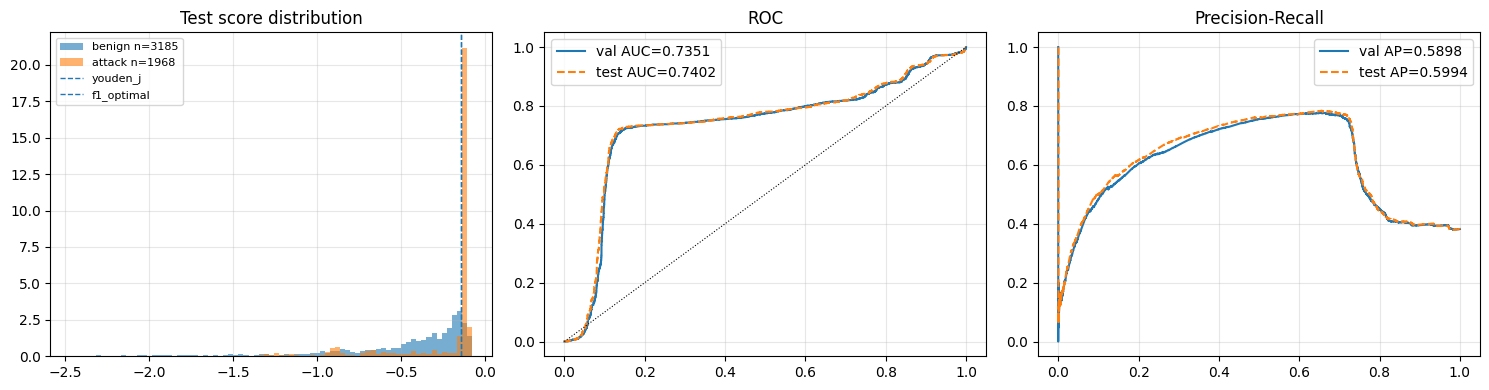

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
s_bn = s_test[y_test == 0]; s_at = s_test[y_test == 1]
hi = np.percentile(s_test, 99); bins = np.linspace(np.percentile(s_test, 1), hi, 80)
ax[0].hist(s_bn, bins=bins, alpha=0.6, label=f'benign n={len(s_bn)}', density=True)
ax[0].hist(s_at, bins=bins, alpha=0.6, label=f'attack n={len(s_at)}', density=True)
for k in ('youden_j','f1_optimal'):
    if k in thresholds: ax[0].axvline(thresholds[k], ls='--', lw=1, label=k)
ax[0].set_title('Test score distribution'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for split, s, y, ls in [('val', s_val, y_val, '-'), ('test', s_test, y_test, '--')]:
    f, t, _ = roc_curve(y, s)
    ax[1].plot(f, t, ls=ls, label=f'{split} AUC={roc_auc_score(y, s):.4f}')
ax[1].plot([0,1],[0,1],'k:',lw=0.8); ax[1].set_title('ROC'); ax[1].grid(alpha=0.3); ax[1].legend()
for split, s, y, ls in [('val', s_val, y_val, '-'), ('test', s_test, y_test, '--')]:
    p, r, _ = precision_recall_curve(y, s)
    ax[2].plot(r, p, ls=ls, label=f'{split} AP={average_precision_score(y, s):.4f}')
ax[2].set_title('Precision-Recall'); ax[2].grid(alpha=0.3); ax[2].legend()
plt.tight_layout(); plt.savefig(RUN_DIR / 'eval_vnext.png', dpi=140); plt.show()

## 13. Multi-seed evaluation (variance control)
Retrain with seeds [42, 7, 1337] using the default config and report mean ± std for the F1-optimal threshold. Demonstrates that the headline number is not a single lucky seed.

In [14]:
def run_single_seed(seed):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    m = build_model(n_features)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE,
                        shuffle=True, drop_last=False, pin_memory=False, num_workers=0)
    tr, _ = train_one(m, loader, X_val_t, y_val, verbose=False)
    sv = compute_scores(X_val, feat_std=None, _model=m)
    st = compute_scores(X_test, feat_std=None, _model=m)
    if AUTO_SCORE_FLIP and roc_auc_score(y_val, -sv) > roc_auc_score(y_val, sv):
        sv, st = -sv, -st
    thr = thresholds_from_val(sv, y_val)
    r   = full_eval(st, y_test, thr['f1_optimal'])
    del m, loader; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return r, tr['best_val_auc'], tr['final_epoch']

seed_results = []
for s in SEEDS:
    r, bv, ep = run_single_seed(s)
    print(f'seed={s:>5}  best_val_auc={bv:.4f}  epoch={ep:>3}  '
          f'test ROC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  MCC={r["mcc"]:.4f}')
    seed_results.append({'seed': s, 'best_val_auc': bv, 'final_epoch': ep, **r})

agg_keys = ['roc_auc', 'pr_auc', 'f1', 'mcc', 'bal_acc', 'fpr', 'fnr']
agg = {k: (float(np.mean([r[k] for r in seed_results])),
           float(np.std ([r[k] for r in seed_results]))) for k in agg_keys}
print('\nmulti-seed summary (mean +/- std)')
for k, (m_, s_) in agg.items(): print(f'  {k:<8} {m_:.4f} +/- {s_:.4f}')

/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


early stop @ epoch 12  best_auc=0.7462  best_mse=0.05266
restored: AUC (0.7462)
seed=   42  best_val_auc=0.7462  epoch= 12  test ROC=0.7491  F1=0.7283  MCC=0.5598


/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


early stop @ epoch 12  best_auc=0.7786  best_mse=0.05358
restored: AUC (0.7786)
seed=    7  best_val_auc=0.7786  epoch= 12  test ROC=0.7828  F1=0.7575  MCC=0.6330


/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


early stop @ epoch 12  best_auc=0.7261  best_mse=0.05379
restored: AUC (0.7261)
seed= 1337  best_val_auc=0.7261  epoch= 12  test ROC=0.7266  F1=0.7163  MCC=0.5385

multi-seed summary (mean +/- std)
  roc_auc  0.7529 +/- 0.0231
  pr_auc   0.6137 +/- 0.0603
  f1       0.7341 +/- 0.0173
  mcc      0.5771 +/- 0.0405
  bal_acc  0.7849 +/- 0.0143
  fpr      0.1473 +/- 0.0414
  fnr      0.2830 +/- 0.0140


## 14. Drift monitor (PSI + KS on holdout vs benign train baseline)
Reads `drift_baseline_vnext.npz`. Reports per-feature PSI and KS distances on the (test) windows vs the training benign baseline. Establishes the foundation for an automated retrain trigger (PSI > 0.25 = major drift).

In [15]:
if drift_z is None:
    print('No drift baseline -- skip')
else:
    q_levels = drift_z['q_levels']
    q_base   = drift_z['q']            # (Q, F)
    def psi_per_feature(X, bins_per_feat):
        F_ = X.shape[2]
        flat = X.reshape(-1, F_)
        psis = np.zeros(F_, dtype=np.float32)
        for j in range(F_):
            edges = np.unique(bins_per_feat[:, j])
            if len(edges) < 3:
                psis[j] = 0.0; continue
            edges[0] = -np.inf; edges[-1] = np.inf
            base_hist, _ = np.histogram(bins_per_feat[:, j], bins=edges)
            curr_hist, _ = np.histogram(flat[:, j],          bins=edges)
            base_p = (base_hist + 1) / (base_hist.sum() + len(edges) - 1)
            curr_p = (curr_hist + 1) / (curr_hist.sum() + len(edges) - 1)
            psis[j] = float(np.sum((curr_p - base_p) * np.log(curr_p / base_p)))
        return psis
    def ks_per_feature(X, base_q, q_levels):
        F_ = X.shape[2]
        flat = X.reshape(-1, F_)
        ks = np.zeros(F_, dtype=np.float32)
        for j in range(F_):
            curr_q = np.quantile(flat[:, j], q_levels)
            base   = base_q[:, j]
            ks[j]  = float(np.max(np.abs(curr_q - base)))
        return ks
    # use baseline q array as the histogram edges (per feature)
    psi = psi_per_feature(X_test, q_base)
    ks  = ks_per_feature (X_test, q_base, q_levels)
    n_major = int((psi > 0.25).sum()); n_minor = int(((psi > 0.10) & (psi <= 0.25)).sum())
    print(f'PSI features: major (>0.25)={n_major}   moderate (0.10-0.25)={n_minor}')
    print(f'KS  median={float(np.median(ks)):.4f}  max={float(ks.max()):.4f}')
    top_psi = np.argsort(psi)[::-1][:8]
    print('top PSI features:')
    for j in top_psi: print(f'  idx={int(j):>4}  PSI={psi[j]:.3f}  KS={ks[j]:.3f}')
    np.savez_compressed(RUN_DIR / 'drift_report_vnext.npz', psi=psi, ks=ks)

PSI features: major (>0.25)=99   moderate (0.10-0.25)=30
KS  median=0.6166  max=3.2872
top PSI features:
  idx=  33  PSI=0.685  KS=1.916
  idx= 138  PSI=0.646  KS=0.749
  idx= 159  PSI=0.627  KS=1.208
  idx=  20  PSI=0.602  KS=0.011
  idx=  34  PSI=0.590  KS=1.375
  idx= 142  PSI=0.577  KS=0.688
  idx=   3  PSI=0.570  KS=0.157
  idx=  19  PSI=0.570  KS=0.018


## 15. Optuna HPO (compact)
Bottleneck swept in {16, 24, 32}. Objective = max(val raw AUC, val flip AUC) to make HPO robust to direction. Best params are then retrained with the full pipeline.

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hpo_objective(trial):
    cfg = dict(
        d_model        = trial.suggest_categorical('d_model',        [64, 96]),
        bottleneck_dim = trial.suggest_categorical('bottleneck_dim', [16, 24, 32]),
        num_enc_layers = trial.suggest_int('num_enc_layers', 1, 3),
        num_dec_layers = trial.suggest_int('num_dec_layers', 1, 2),
        dim_ff         = trial.suggest_categorical('dim_ff', [192, 256, 320]),
        dropout        = trial.suggest_float('dropout', 0.05, 0.30),
    )
    lr        = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    noise_std = trial.suggest_float('noise_std', 0.01, 0.06)
    cl        = trial.suggest_float('contractive_lambda', 0.0, 5e-3)
    nhead = 4 if cfg['d_model'] % 4 == 0 else 2
    m = build_model(n_features, d_model=cfg['d_model'], nhead=nhead,
                    num_enc_layers=cfg['num_enc_layers'],
                    num_dec_layers=cfg['num_dec_layers'],
                    dim_ff=cfg['dim_ff'], dropout=cfg['dropout'],
                    bottleneck_dim=cfg['bottleneck_dim'])
    loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE,
                        shuffle=True, drop_last=False, pin_memory=False, num_workers=0)
    res, _ = train_one(m, loader, X_val_t, y_val,
                       max_epochs=HPO_MAX_EPOCH, lr=lr,
                       noise_std=noise_std, contractive_lambda=cl,
                       auc_patience=HPO_PATIENCE, min_epoch=4, verbose=False)
    val_auc = res['best_val_auc']
    del m, loader; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return float(val_auc)

study = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=MAIN_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
print(f'Starting HPO: {N_TRIALS} trials, {HPO_MAX_EPOCH} epochs each')
study.optimize(hpo_objective, n_trials=N_TRIALS, show_progress_bar=True)
best = study.best_trial
print(f'Best Val AUC: {best.value:.4f}')
print(f'Best params : {best.params}')

Starting HPO: 12 trials, 18 epochs each


  0%|          | 0/12 [00:00<?, ?it/s]

/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


early stop @ epoch 16  best_auc=0.6790  best_mse=0.04863
restored: AUC (0.6790)


/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


...

early stop @ epoch 12  best_auc=0.7580  best_mse=0.05448
restored: AUC (0.7580)


/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


early stop @ epoch 10  best_auc=0.7624  best_mse=0.10601
restored: AUC (0.7624)


/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


early stop @ epoch 10  best_auc=0.8019  best_mse=0.13512
restored: AUC (0.8019)
Best Val AUC: 0.8019
Best params : {'d_model': 64, 'bottleneck_dim': 16, 'num_enc_layers': 3, 'num_dec_layers': 2, 'dim_ff': 192, 'dropout': 0.16059582234952724, 'lr': 0.00010739354622074816, 'noise_std': 0.010435561573088638, 'contractive_lambda': 0.0022593854685372225}


## 16. Retrain with best HPO params + full evaluation

In [17]:
bp = best.params
nhead_best = 4 if bp['d_model'] % 4 == 0 else 2
model_best = build_model(
    n_features=n_features, d_model=bp['d_model'], nhead=nhead_best,
    num_enc_layers=bp['num_enc_layers'], num_dec_layers=bp['num_dec_layers'],
    dim_ff=bp['dim_ff'], dropout=bp['dropout'],
    bottleneck_dim=bp['bottleneck_dim'])
loader_best = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE,
                         shuffle=True, drop_last=False, pin_memory=False, num_workers=0)
tr_best, _ = train_one(model_best, loader_best, X_val_t, y_val,
                       lr=bp['lr'], noise_std=bp['noise_std'],
                       contractive_lambda=bp['contractive_lambda'],
                       verbose=True)

sv = compute_scores(X_val,  feat_std=None, _model=model_best)
st = compute_scores(X_test, feat_std=None, _model=model_best)
if AUTO_SCORE_FLIP and roc_auc_score(y_val, -sv) > roc_auc_score(y_val, sv):
    sv, st = -sv, -st
thr_best = thresholds_from_val(sv, y_val)
r_best = full_eval(st, y_test, thr_best['f1_optimal'])
print('HPO best on test (F1-optimal threshold):')
for k in ('roc_auc','pr_auc','f1','mcc','bal_acc','fpr','fnr'):
    print(f'  {k:<8} {r_best[k]:.4f}')

/tmp/ipykernel_463/2076305318.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


epoch 001  train=0.77467  val_benign=0.52621  lr=1.1e-04
epoch 002  train=0.56204  val_benign=0.48523  lr=1.1e-04  val_auc=0.8134
epoch 004  train=0.41680  val_benign=0.27732  lr=1.1e-04  val_auc=0.7245
epoch 006  train=0.31872  val_benign=0.19553  lr=1.1e-04  val_auc=0.5149
epoch 008  train=0.26307  val_benign=0.15359  lr=1.1e-04  val_auc=0.5103
epoch 010  train=0.22684  val_benign=0.13644  lr=1.1e-04  val_auc=0.5154
epoch 012  train=0.20244  val_benign=0.12373  lr=1.1e-04  val_auc=0.5034
early stop @ epoch 12  best_auc=0.8134  best_mse=0.12373
restored: AUC (0.8134)
HPO best on test (F1-optimal threshold):
  roc_auc  0.8138
  pr_auc   0.6062
  f1       0.7736
  mcc      0.6260
  bal_acc  0.8172
  fpr      0.1705
  fnr      0.1951


## 17. Save artifacts + metrics summary

In [18]:
from datetime import datetime, timezone

torch.save({
    'model_default': model.state_dict(),
    'model_best'   : model_best.state_dict(),
    'hpo_params'   : bp,
    'feat_std'     : feat_std,
    'config': {
        'T': T, 'n_features': n_features,
        'd_model': D_MODEL, 'bottleneck_dim': BOTTLENECK_DIM,
        'nhead': N_HEAD, 'num_enc_layers': N_ENC_LAYERS,
        'num_dec_layers': N_DEC_LAYERS, 'dim_ff': DIM_FF, 'dropout': DROPOUT,
    },
}, RUN_DIR / 'checkpoint_vnext.pt')

np.savez_compressed(RUN_DIR / 'scores_vnext.npz',
    s_val=s_val, s_test=s_test, y_val=y_val, y_test=y_test)

summary = {
    'created_at'     : datetime.now(timezone.utc).isoformat(),
    'version'        : VERSION,
    'architecture'   : 'SequenceBottleneckAE (no temporal mean-pool)',
    'auto_score_flip': bool(SCORE_INVERT),
    'primary_threshold': 'f1_optimal',
    'test_default'   : all_results,
    'test_hpo'       : r_best,
    'multi_seed'     : {k: {'mean': v[0], 'std': v[1]} for k, v in agg.items()},
    'hpo_best_params': bp,
    'data_scale'     : {'mean_abs': _xmean, 'max_abs': _xmax, 'nan': _nan},
    'train_shapes'   : {'X_train': list(X_train_t.shape),
                        'X_val'  : list(X_val.shape),
                        'X_test' : list(X_test.shape)},
}
(RUN_DIR / 'metrics_vnext.json').write_text(json.dumps(summary, indent=2))
print('Saved artifacts to', RUN_DIR)
print(json.dumps({k: round(v, 4) for k, v in {
    'default_test_roc' : all_results['f1_optimal']['roc_auc'],
    'default_test_f1'  : all_results['f1_optimal']['f1'],
    'default_test_mcc' : all_results['f1_optimal']['mcc'],
    'hpo_test_roc'     : r_best['roc_auc'],
    'hpo_test_f1'      : r_best['f1'],
    'hpo_test_mcc'     : r_best['mcc'],
    'mean_seed_roc'    : agg['roc_auc'][0],
    'mean_seed_mcc'    : agg['mcc'][0],
}.items()}, indent=2))

# Local cache for eval notebook + reliable Drive export (FUSE writes alone may not sync)
import shutil
LOCAL_RUN_DIR = Path('/content/vnext_run_local')
LOCAL_RUN_DIR.mkdir(parents=True, exist_ok=True)
_artifact_names = [
    'checkpoint_vnext.pt', 'scores_vnext.npz', 'metrics_vnext.json',
    'eval_vnext.png', 'drift_report_vnext.npz',
]
for _name in _artifact_names:
    _src = RUN_DIR / _name
    if _src.is_file():
        shutil.copy2(_src, LOCAL_RUN_DIR / _name)
print(f'Local cache -> {LOCAL_RUN_DIR}')
for _f in sorted(LOCAL_RUN_DIR.glob('*')):
    print(f'  {_f.name:30s}  {_f.stat().st_size:>12,} bytes')

Saved artifacts to /content/drive/MyDrive/Module4_MDC/runs/vnext_run
{
  "default_test_roc": 0.7402,
  "default_test_f1": 0.7412,
  "default_test_mcc": 0.5884,
  "hpo_test_roc": 0.8138,
  "hpo_test_f1": 0.7736,
  "hpo_test_mcc": 0.626,
  "mean_seed_roc": 0.7529,
  "mean_seed_mcc": 0.5771
}
Local cache -> /content/vnext_run_local
  checkpoint_vnext.pt                2,356,857 bytes
  drift_report_vnext.npz                 1,541 bytes
  eval_vnext.png                        93,106 bytes
  metrics_vnext.json                     4,166 bytes
  scores_vnext.npz                      41,091 bytes


## 17b. Persist to Drive `runs/vnext_run/` (fix FUSE sync)

Colab FUSE often shows files via `ls` but **does not sync** them to the Drive web UI.
Saves to `/content/vnext_run_local/` first, then gentle `shutil.copy2` to Drive (no `force_remount`).

In [19]:
import shutil

LOCAL_RUN_DIR = Path('/content/vnext_run_local')
DRIVE_RUN_DIR = Path('/content/drive/MyDrive/Module4_MDC/runs/vnext_run')
_export_names = [
    'checkpoint_vnext.pt', 'scores_vnext.npz', 'metrics_vnext.json',
    'eval_vnext.png', 'drift_report_vnext.npz',
]

if not LOCAL_RUN_DIR.is_dir() or not any(LOCAL_RUN_DIR.iterdir()):
    raise FileNotFoundError(
        f'{LOCAL_RUN_DIR} empty — run section 17 (cell-save) first')

if _IN_COLAB:
    from google.colab import drive
    _mount = '/content/drive'
    if not os.path.isdir(os.path.join(_mount, 'MyDrive')):
        os.makedirs(_mount, exist_ok=True)
        drive.mount(_mount)
        print('Drive mounted (fresh)')
    else:
        print('Drive already mounted — copying without remount')
    DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)
    for name in _export_names:
        src = LOCAL_RUN_DIR / name
        if src.is_file():
            shutil.copy2(src, DRIVE_RUN_DIR / name)
            print(f'Copied -> {DRIVE_RUN_DIR / name}')
    print('\n--- verify on mount ---')
    for name in _export_names:
        p = DRIVE_RUN_DIR / name
        print(f'  {name:30s}  exists={p.is_file()}  '
              f'size={p.stat().st_size if p.is_file() else 0:,}')
    print(f'\nLocal cache: {LOCAL_RUN_DIR}')
    print('Refresh drive.google.com -> Module4_MDC/runs/vnext_run/ (may take 1-2 min)')
else:
    print(f'Local only: artifacts in {LOCAL_RUN_DIR}')

Drive already mounted — copying without remount
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/checkpoint_vnext.pt
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/scores_vnext.npz
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/metrics_vnext.json
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/eval_vnext.png
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/drift_report_vnext.npz

--- verify on mount ---
  checkpoint_vnext.pt             exists=True  size=2,356,857
  scores_vnext.npz                exists=True  size=41,091
  metrics_vnext.json              exists=True  size=4,166
  eval_vnext.png                  exists=True  size=93,106
  drift_report_vnext.npz          exists=True  size=1,541

Local cache: /content/vnext_run_local
Refresh drive.google.com -> Module4_MDC/runs/vnext_run/ (may take 1-2 min)


## 18. Comparison vs prior runs
Cross-references this run against historic results so the thesis can quote a single table.

In [20]:
history_table = [
    ('v0  mdc_model_training', 0.6415, None,   None,   '54+1 feat, RobustScaler, no bucket scaler'),
    ('v2  default',            0.5425, 0.3305, 0.8092, 'mean+max+std, mean-pool decoder'),
    ('v2  HPO retrain',        0.6407, 0.4766, 0.8388, 'mean+max+std, HPO'),
    ('v3  run 2 (Robust)',     None,   None,   None,   'BAD scale (MSE ~1e11)'),
    ('v3  run 3 (Exp1 56f)',   0.1582, -0.1666,0.5345, 'mean-only, inverted'),
    ('v3  run 4 (Exp A)',      0.7163, 0.5278, 0.7105, 'best Exp A default'),
    ('vNext default',          all_results['f1_optimal']['roc_auc'],
                               all_results['f1_optimal']['mcc'],
                               all_results['f1_optimal']['f1'],
                               '+contractive, +ensemble, +F1-thr'),
    ('vNext HPO',              r_best['roc_auc'], r_best['mcc'], r_best['f1'],
                               'HPO best'),
]
print(f'{"run":<25} {"ROC-AUC":>8} {"MCC":>8} {"F1":>8}  notes')
print('-'*78)
for row in history_table:
    name, roc, mcc, f1, notes = row
    rs = f'{roc:>8.4f}' if isinstance(roc,(int,float)) else f'{"-":>8}'
    ms = f'{mcc:>8.4f}' if isinstance(mcc,(int,float)) else f'{"-":>8}'
    fs = f'{f1 :>8.4f}' if isinstance(f1 ,(int,float)) else f'{"-":>8}'
    print(f'{name:<25} {rs} {ms} {fs}  {notes}')

run                        ROC-AUC      MCC       F1  notes
------------------------------------------------------------------------------
v0  mdc_model_training      0.6415        -        -  54+1 feat, RobustScaler, no bucket scaler
v2  default                 0.5425   0.3305   0.8092  mean+max+std, mean-pool decoder
v2  HPO retrain             0.6407   0.4766   0.8388  mean+max+std, HPO
v3  run 2 (Robust)               -        -        -  BAD scale (MSE ~1e11)
v3  run 3 (Exp1 56f)        0.1582  -0.1666   0.5345  mean-only, inverted
v3  run 4 (Exp A)           0.7163   0.5278   0.7105  best Exp A default
vNext default               0.7402   0.5884   0.7412  +contractive, +ensemble, +F1-thr
vNext HPO                   0.8138   0.6260   0.7736  HPO best


## 19. Per-attack-type evaluation (multiclass)

Uses **in-memory** `s_test` / `y_test` from this run (no reload from npz — avoids cross-runtime issues).
Loads `y_test_multiclass` from `windows_vnext_mc.npz` (run `mdc_preprocess_vNext_mc.ipynb` first).

Reports recall per MDC attack label (0–11) at the **f1_optimal** threshold from §10.

In [21]:
import subprocess

def _find_npz(name):
    r = subprocess.run(['find', '/content', '-name', name],
                       capture_output=True, text=True)
    hits = [h for h in r.stdout.strip().splitlines() if h]
    return Path(hits[0]) if hits else None

MC_NPZ = DATA_DIR / 'windows_vnext_mc.npz'
if not MC_NPZ.is_file():
    MC_NPZ = Path('/content/drive/MyDrive/Module4_MDC/processed_vnext/windows_vnext_mc.npz')
if not MC_NPZ.is_file():
    MC_NPZ = _find_npz('windows_vnext_mc.npz')
if not MC_NPZ or not MC_NPZ.is_file():
    print('windows_vnext_mc.npz not on mount — gdown fallback ...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=False)
    import gdown
    _mc_cache = Path('/content/mc_cache')
    _mc_cache.mkdir(exist_ok=True)
    gdown.download_folder(id=DRIVE_PROCESSED_FOLDER_ID, output=str(_mc_cache), quiet=False)
    MC_NPZ = _find_npz('windows_vnext_mc.npz')

if not MC_NPZ or not MC_NPZ.is_file():
    raise FileNotFoundError(
        'windows_vnext_mc.npz not found. Run mdc_preprocess_vNext_mc.ipynb first.')

print(f'MC_NPZ: {MC_NPZ}')
_mc = np.load(MC_NPZ, allow_pickle=True)
y_test_mc = _mc['y_test_multiclass'].astype(int)
y_test_mc_bin = _mc['y_test'].astype(np.int64)
_mc.close()

assert len(y_test_mc) == len(y_test), f'length mismatch mc={len(y_test_mc)} test={len(y_test)}'
_n_bad = int((y_test_mc_bin != y_test).sum())
if _n_bad:
    raise ValueError(f'{_n_bad} y_test mismatches — rerun mc preprocess with RANDOM_STATE=42')
print('Alignment: PASS (y_test matches windows_vnext_mc.npz)')
print(f'Unique multiclass labels on test: {sorted(np.unique(y_test_mc).tolist())}')

MC_NPZ: /content/processed_vnext/windows_vnext_mc.npz
Alignment: PASS (y_test matches windows_vnext_mc.npz)
Unique multiclass labels on test: [0, 1, 2, 3, 4, 8, 11]


 Label  Name                     Windows   Detected   Recall/FPR  Note
---------------------------------------------------------------------------
     0  BENIGN                     3,184        447       0.1404  FPR *
     1  Attack_1                   1,679      1,416       0.8434  Recall
     2  Attack_2                     266          6       0.0226  Recall
     3  Attack_3                       1          0       0.0000  Recall
     4  Attack_4                       1          0       0.0000  Recall
     8  Attack_8                      19          0       0.0000  Recall
    11  Attack_11                      3          0       0.0000  Recall

Threshold: -0.1434 (f1_optimal)  |  ROC-AUC: 0.7402


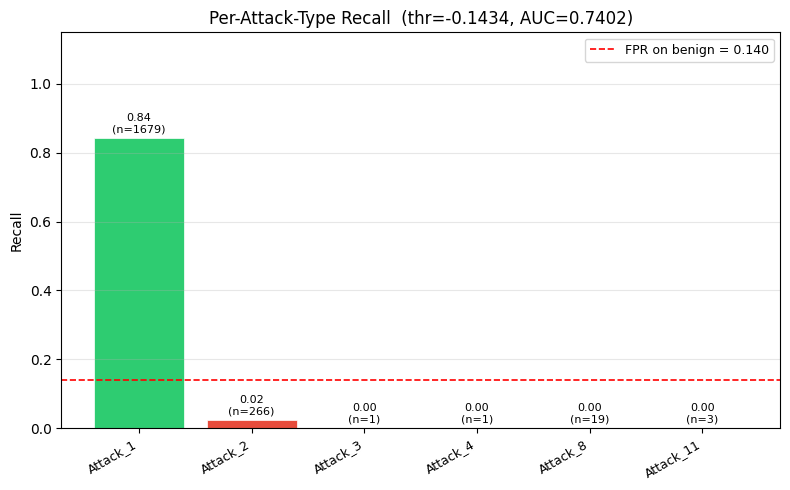

Saved -> /content/vnext_run_local/eval_per_attack_type.png


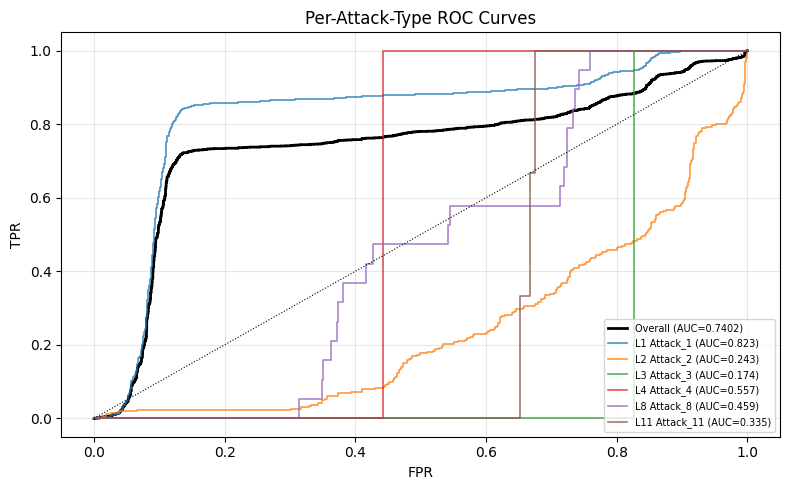

Saved -> /content/vnext_run_local/eval_per_attack_roc.png
Saved -> /content/vnext_run_local/eval_multiclass.json
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/eval_per_attack_type.png
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/eval_per_attack_roc.png
Copied -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/eval_multiclass.json


In [22]:
from collections import Counter
from sklearn.metrics import roc_auc_score, roc_curve

# Update LABEL_NAMES from mdc_eda / dataset docs when known
LABEL_NAMES = {
    0: 'BENIGN', 1: 'Attack_1', 2: 'Attack_2', 3: 'Attack_3', 4: 'Attack_4',
    5: 'Attack_5', 6: 'Attack_6', 7: 'Attack_7', 8: 'Attack_8',
    9: 'Attack_9', 10: 'Attack_10', 11: 'Attack_11',
}

THRESHOLD   = float(thresholds['f1_optimal'])
overall_auc = float(roc_auc_score(y_test, s_test))
pred_test   = (s_test >= THRESHOLD).astype(int)
_mc_out = Path('/content/vnext_run_local')
if not _mc_out.is_dir():
    _mc_out = RUN_DIR
_mc_out.mkdir(parents=True, exist_ok=True)

rows = []
benign_mask = y_test_mc == 0
n_benign    = int(benign_mask.sum())
fp_benign   = int(pred_test[benign_mask].sum())
fpr_benign  = fp_benign / n_benign if n_benign else 0.0
rows.append({'label': 0, 'name': 'BENIGN', 'n_windows': n_benign,
             'detected': fp_benign, 'recall_fpr': fpr_benign, 'note': 'FPR'})

for lbl in sorted(l for l in np.unique(y_test_mc) if l != 0):
    mask = y_test_mc == lbl
    n_win = int(mask.sum())
    tp    = int(pred_test[mask].sum())
    rows.append({'label': int(lbl), 'name': LABEL_NAMES.get(lbl, f'Attack_{lbl}'),
                 'n_windows': n_win, 'detected': tp,
                 'recall_fpr': tp / n_win if n_win else 0.0, 'note': 'Recall'})

print(f'{"Label":>6}  {"Name":<22}  {"Windows":>8}  {"Detected":>9}  {"Recall/FPR":>11}  Note')
print('-' * 75)
for r in rows:
    star = ' *' if r['label'] == 0 else ''
    print(f'{r["label"]:>6}  {r["name"]:<22}  {r["n_windows"]:>8,}  '
          f'{r["detected"]:>9,}  {r["recall_fpr"]:>11.4f}  {r["note"]}{star}')
print(f'\nThreshold: {THRESHOLD:.4f} (f1_optimal)  |  ROC-AUC: {overall_auc:.4f}')

# Bar chart
atk_rows = [r for r in rows if r['label'] != 0]
fig, ax = plt.subplots(figsize=(max(8, len(atk_rows) * 1.2), 5))
recalls = [r['recall_fpr'] for r in atk_rows]
names   = [r['name'] for r in atk_rows]
n_wins  = [r['n_windows'] for r in atk_rows]
colors  = ['#2ecc71' if r >= 0.80 else '#f39c12' if r >= 0.50 else '#e74c3c' for r in recalls]
bars = ax.bar(range(len(names)), recalls, color=colors, edgecolor='white', linewidth=0.5)
for bar, r, n in zip(bars, recalls, n_wins):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{r:.2f}\n(n={n})', ha='center', va='bottom', fontsize=8)
ax.axhline(fpr_benign, color='red', linestyle='--', linewidth=1.2,
           label=f'FPR on benign = {fpr_benign:.3f}')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.15)
ax.set_title(f'Per-Attack-Type Recall  (thr={THRESHOLD:.4f}, AUC={overall_auc:.4f})')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
_mc_plot = _mc_out / 'eval_per_attack_type.png'
plt.savefig(_mc_plot, dpi=140); plt.show()
print(f'Saved -> {_mc_plot}')

# Per-attack ROC overlay
fig, ax = plt.subplots(figsize=(8, 5))
fpr_b, tpr_b, _ = roc_curve(y_test, s_test)
ax.plot(fpr_b, tpr_b, 'k-', lw=2, label=f'Overall (AUC={overall_auc:.4f})')
for lbl in sorted(l for l in np.unique(y_test_mc) if l != 0):
    mask = (y_test_mc == lbl) | (y_test_mc == 0)
    _y = (y_test_mc[mask] != 0).astype(int)
    _s = s_test[mask]
    if _y.sum() == 0 or _y.sum() == len(_y):
        continue
    try:
        _auc = float(roc_auc_score(_y, _s))
        _fp, _tp, _ = roc_curve(_y, _s)
        ax.plot(_fp, _tp, lw=1.2, alpha=0.8,
                label=f'L{lbl} {LABEL_NAMES.get(lbl, "")} (AUC={_auc:.3f})')
    except Exception:
        pass
ax.plot([0, 1], [0, 1], 'k:', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Per-Attack-Type ROC Curves')
ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
_mc_roc = _mc_out / 'eval_per_attack_roc.png'
plt.savefig(_mc_roc, dpi=140); plt.show()
print(f'Saved -> {_mc_roc}')

# JSON export
mc_results = {
    'threshold': THRESHOLD,
    'overall_roc_auc': overall_auc,
    'fpr_on_benign': fpr_benign,
    'per_attack_type': [
        {'label': r['label'], 'name': r['name'], 'n_windows': r['n_windows'],
         'detected': r['detected'],
         'recall': r['recall_fpr'] if r['label'] != 0 else None,
         'fpr': r['recall_fpr'] if r['label'] == 0 else None}
        for r in rows],
}
_mc_json = _mc_out / 'eval_multiclass.json'
_mc_json.write_text(json.dumps(mc_results, indent=2))
print(f'Saved -> {_mc_json}')
if _IN_COLAB:
    import shutil
    _drive_out = Path('/content/drive/MyDrive/Module4_MDC/runs/vnext_run')
    if _drive_out.is_dir():
        for _f in (_mc_plot, _mc_roc, _mc_json):
            if _f.is_file():
                shutil.copy2(_f, _drive_out / _f.name)
                print(f'Copied -> {_drive_out / _f.name}')